# Feature Engineering & ML Dataset Preparation

## Objective

The goal of this notebook is to transform raw transactional data into a machine-learning-ready feature dataset.

The engineered features created here will be reused across multiple predictive models including:

- Customer Lifetime Value Prediction
- Sales Forecasting
- Recommendation Systems
- Churn Prediction (future extension)

In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import warnings 
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 

In [6]:

project_root = Path.cwd().parent.parent
data_dir = project_root / "datasets" / "Olist"

In [8]:
orders = pd.read_csv(
    data_dir/"olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

customers = pd.read_csv(
    data_dir/"olist_customers_dataset.csv"
)

payments = pd.read_csv(
    data_dir/"olist_order_payments_dataset.csv"
)

order_items = pd.read_csv(
    data_dir/"olist_order_items_dataset.csv"
)

reviews = pd.read_csv(
    data_dir/"olist_order_reviews_dataset.csv"
)

In [9]:
master = (
    customers
    .merge(orders,on="customer_id")
    .merge(payments,on="order_id")
    .merge(order_items,on="order_id")
    .merge(reviews,on="order_id",how="left")
)

master.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,seller_id,shipping_limit_date,price,freight_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,88b8b52d46df026a9d1ad2136a59b30b,4.0,NaN,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,NaN,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,5ad6695d76ee186dc473c42706984d87,5.0,NaN,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,059a801bb31f6aab2266e672cab87bc5,5.0,NaN,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,8490879d58d6c5d7773f2739a03f089a,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52


In [10]:
snapshot = (
    master["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

customer_features = (
    master
    .groupby("customer_unique_id")
    .agg(
        Recency=(
            "order_purchase_timestamp",
            lambda x:(snapshot-x.max()).days
        ),
        Frequency=("order_id","nunique"),
        Monetary=("payment_value","sum"),
        AvgOrderValue=("payment_value","mean"),
        AvgReview=("review_score","mean")
    )
)

In [11]:
master["Delivery_Days"] = (
    master["order_delivered_customer_date"]
    - master["order_purchase_timestamp"]
).dt.days

master["Delay_Days"] = (
    master["order_delivered_customer_date"]
    - master["order_estimated_delivery_date"]
).dt.days

delivery_features = (
    master
    .groupby("customer_unique_id")
    .agg(
        AvgDelivery=("Delivery_Days","mean"),
        AvgDelay=("Delay_Days","mean")
    )
)

In [12]:
payment_features = (
    master
    .groupby("customer_unique_id")
    .agg(
        AvgPayment=("payment_value","mean"),
        MaxPayment=("payment_value","max"),
        TotalPayment=("payment_value","sum")
    )
)

In [13]:
master["PurchaseMonth"] = (
    master["order_purchase_timestamp"].dt.month
)

master["PurchaseDay"] = (
    master["order_purchase_timestamp"].dt.dayofweek
)

time_features = (
    master
    .groupby("customer_unique_id")
    .agg(
        FavoriteMonth=("PurchaseMonth",lambda x:x.mode()[0]),
        FavoriteDay=("PurchaseDay",lambda x:x.mode()[0])
    )
)

In [14]:
ml_dataset = (
    customer_features
    .join(delivery_features)
    .join(payment_features)
    .join(time_features)
)

ml_dataset.head()

,Recency,Frequency,Monetary,AvgOrderValue,AvgReview,AvgDelivery,AvgDelay,AvgPayment,MaxPayment,TotalPayment,FavoriteMonth,FavoriteDay
customer_unique_id,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,141.90,5.0,6.0,-5.0,141.90,141.90,141.90,5,3
0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,27.19,4.0,3.0,-5.0,27.19,27.19,27.19,5,0
0000f46a3911fa3c0805444483337064,542,1,86.22,86.22,3.0,25.0,-2.0,86.22,86.22,86.22,3,4
0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,43.62,4.0,20.0,-12.0,43.62,43.62,43.62,10,3
0004aac84e0df4da2b147fca70cf8255,293,1,196.89,196.89,5.0,13.0,-8.0,196.89,196.89,196.89,11,1


In [15]:
ml_dataset.fillna(
    ml_dataset.median(numeric_only=True),
    inplace=True
)

,Recency,Frequency,Monetary,AvgOrderValue,AvgReview,AvgDelivery,AvgDelay,AvgPayment,MaxPayment,TotalPayment,FavoriteMonth,FavoriteDay
customer_unique_id,,,,,,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,141.90,5.0,6.0,-5.0,141.90,141.90,141.90,5,3
0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,27.19,4.0,3.0,-5.0,27.19,27.19,27.19,5,0
0000f46a3911fa3c0805444483337064,542,1,86.22,86.22,3.0,25.0,-2.0,86.22,86.22,86.22,3,4
0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,43.62,4.0,20.0,-12.0,43.62,43.62,43.62,10,3
0004aac84e0df4da2b147fca70cf8255,293,1,196.89,196.89,5.0,13.0,-8.0,196.89,196.89,196.89,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,452,1,4134.84,2067.42,5.0,27.0,-27.0,2067.42,2067.42,4134.84,6,3
fffea47cd6d3cc0a88bd621562a9d061,267,1,84.58,84.58,4.0,30.0,-3.0,84.58,84.58,84.58,12,6
ffff371b4d645b6ecea244b27531430a,573,1,112.46,112.46,5.0,14.0,-30.0,112.46,112.46,112.46,2,1


In [16]:
scaler = StandardScaler()

scaled = scaler.fit_transform(ml_dataset)

scaled_df = pd.DataFrame(
    scaled,
    columns=ml_dataset.columns,
    index=ml_dataset.index
)

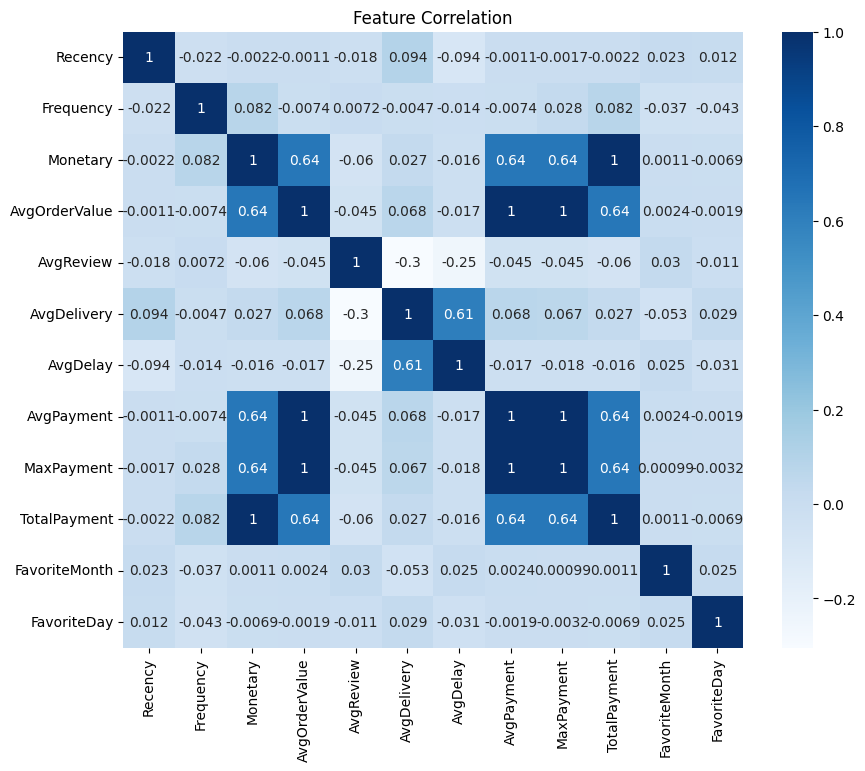

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    ml_dataset.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation")

plt.show()

In [18]:
scaled_df.to_csv(
    "customer_ml_dataset.csv"
)

print("ML dataset saved successfully.")

ML dataset saved successfully.
